In [12]:
import data_loader
import plotting
import dispatch
from pathlib import Path
import pandas as pd
import numpy as np
import scenarios
from functools import partial

#CONSTANTS
CCGT_POWER=400 #MW
HEAT_RATE=1.95 #MW of gas to produce 1 MW of electricy
SWITCH_ON_COST=15000 #EUR
MIN_ON_TIME=4 #HOURS
MIN_OFF_TIME=4 #HOURS
EMISSION_FACTOR=0.37 # tons of CO2 per MWh of electricity produced
CO2_PRICE=70 #EUR/ton 


# CCGT valuation — data loading and analysis on a past year

Valuation of a combined-cycle gas turbine (CCGT) plant modelled as a
strip of spark-spread options, using 2023 Italian day-ahead electricity
prices (PUN) and Dutch TTF gas prices.

This notebook loads and inspects the price data; the valuation and
dispatch-optimization logic lives in the project modules.

## 1. Load price data

Hourly PUN and daily TTF prices are loaded and aligned by
`data_loader.load_pun_ttf_prices`, which merges the daily gas price onto
the hourly grid (forward-filled over weekends and holidays) and returns
a DataFrame indexed by hour of the year. Running with `diagnostic=True`
checks the load for missing values and the expected per-day hour counts.

In [2]:
year=2025 #available years are 2022 - 2023 - 2024 - 2025 only

pun_ttf_prices=data_loader.load_pun_ttf_prices(diagnostic=True, year=year)

display(pun_ttf_prices.head())
display(pun_ttf_prices.tail())

diagnostic OK: 8760 hours, 365 days (363 x 24h, one 23h, one 25h), no missing values


,time,pun_price,ttf_price
0,2025-01-01 00:00:00,138.69858,48.889
1,2025-01-01 01:00:00,134.06000,48.889
2,2025-01-01 02:00:00,134.41000,48.889
3,2025-01-01 03:00:00,131.99000,48.889
4,2025-01-01 04:00:00,131.99000,48.889


,time,pun_price,ttf_price
8755,2025-12-31 19:00:00,121.000000,28.161
8756,2025-12-31 20:00:00,113.964992,28.161
8757,2025-12-31 21:00:00,111.200000,28.161
8758,2025-12-31 22:00:00,113.565000,28.161
8759,2025-12-31 23:00:00,106.307500,28.161


## 2. Computing and visualizing spark spread

In [3]:
pun_ttf_prices["spark_spread"]=dispatch.compute_spark_spread(
    pun_price=pun_ttf_prices["pun_price"], 
    ttf_price=pun_ttf_prices["ttf_price"], 
    heat_rate=HEAT_RATE, 
    emission_factor=EMISSION_FACTOR, 
    co2_price=CO2_PRICE,
)

pun_ttf_prices.head()

,time,pun_price,ttf_price,spark_spread
0,2025-01-01 00:00:00,138.69858,48.889,17.46503
1,2025-01-01 01:00:00,134.06000,48.889,12.82645
2,2025-01-01 02:00:00,134.41000,48.889,13.17645
3,2025-01-01 03:00:00,131.99000,48.889,10.75645
4,2025-01-01 04:00:00,131.99000,48.889,10.75645


(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Spark spread hourly — sample week'}, ylabel='€/MWh'>)

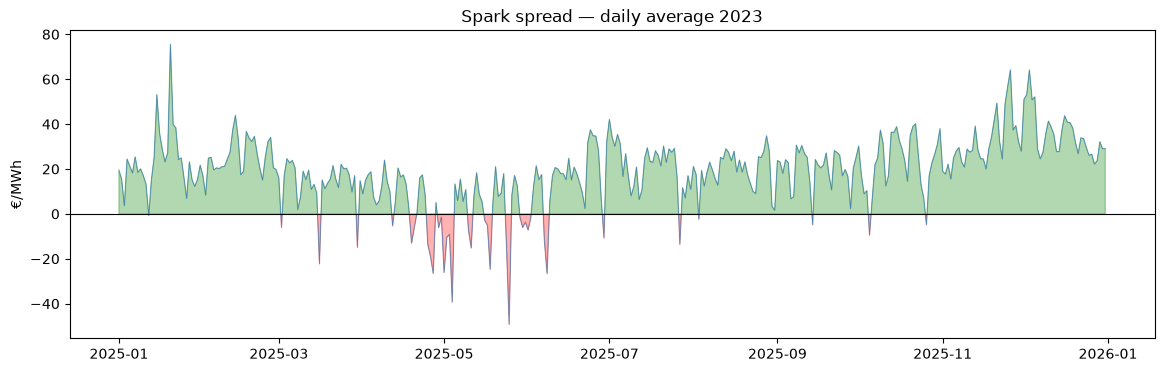

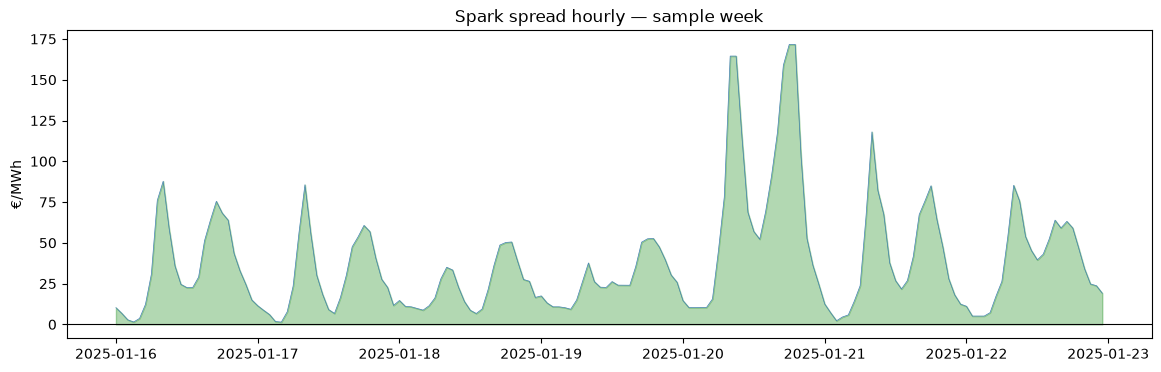

In [4]:
# media giornaliera
daily = (
    pun_ttf_prices.set_index("time")["spark_spread"]
    .resample("D")
    .mean()
)

plotting.plot_series_vs_threshold(
    daily.index, daily.values,
    title="Spark spread — daily average 2023", ylabel="€/MWh",
)

start_week=f"{year}-01-16"
end_week=f"{year}-01-23"
# settimana campione
week = pun_ttf_prices[(pun_ttf_prices["time"] >= start_week) &
              (pun_ttf_prices["time"] < end_week)]
plotting.plot_series_vs_threshold(
    week["time"], week["spark_spread"],
    title="Spark spread hourly — sample week", ylabel="€/MWh",
)

# 3.Optimization Strategies

### Naive Strategy: turbine always ON

In [5]:
total_revs_naive=pun_ttf_prices["spark_spread"].sum()*CCGT_POWER
formatted_revs_naive = f"{total_revs_naive:,.0f}".replace(",", " ")

print(
    f"""By keeping the turbine always ON,
in one year the total gross revenues is {formatted_revs_naive} EUR
"""
)

By keeping the turbine always ON,
in one year the total gross revenues is 67 411 286 EUR



### Ideal Strategy with no constraints: switching is free and always possible

In [6]:
total_revs_ideal=(
    pun_ttf_prices[pun_ttf_prices["spark_spread"]>0]["spark_spread"]
    .sum()*CCGT_POWER
)

formatted_revs_ideal = f"{total_revs_ideal:,.0f}".replace(",", " ")
diff_ideal_naive=total_revs_ideal-total_revs_naive

formatted_diff_ideal_naive = f"{diff_ideal_naive:,.0f}".replace(",", " ")

print(
    "If switching were free and always possible, in one year\n"
    f"the total gross revenues would be {formatted_revs_ideal} EUR,\n"
    f"which is {formatted_diff_ideal_naive} more than keeping\n"
    "the turbine always ON."
)

If switching were free and always possible, in one year
the total gross revenues would be 80 515 254 EUR,
which is 13 103 968 more than keeping
the turbine always ON.


### Optimal Strategy with physical constraints

In [7]:
constraints={
    "min_on_time":MIN_ON_TIME,
    "min_off_time":MIN_OFF_TIME,
    "switch_on_cost": SWITCH_ON_COST,
    "ccgt_power": CCGT_POWER
}

is_on_dispatch, optimal_real_revs = dispatch.compute_optimal_dispatch(
    hourly_prices=pun_ttf_prices, 
    constraints=constraints
)

pun_ttf_prices["optimal_dispatch"]=is_on_dispatch


n_startups=dispatch.count_startups(is_on_dispatch)

formatted_startup_costs= f"{n_startups*SWITCH_ON_COST:,.0f}".replace(",", " ")


formatted_revs_real = f"{optimal_real_revs:,.0f}".replace(",", " ")

run_at_loss=(
    pun_ttf_prices[(
        (pun_ttf_prices["spark_spread"]<0) & 
        (pun_ttf_prices["optimal_dispatch"]==True))]["spark_spread"]
    .sum()*CCGT_POWER
)
formatted_run_at_loss_costs= f"{abs(run_at_loss):,.0f}".replace(",", " ")


off_when_profitable=(
    pun_ttf_prices[
        ((pun_ttf_prices["spark_spread"]>0) & 
        (pun_ttf_prices["optimal_dispatch"]==False))]["spark_spread"]
    .sum()*CCGT_POWER
)
formatted_off_when_profitable_costs= f"{abs(off_when_profitable):,.0f}".replace(",", " ")

optimal_minus_naive=optimal_real_revs-total_revs_naive
formatted_optimal_minus_naive= f"{optimal_minus_naive:,.0f}".replace(",", " ")



### Saving outputs

In [8]:
Path("output").mkdir(parents=True, exist_ok=True)

dispatch_df = pd.DataFrame({
    "hour": range(len(is_on_dispatch)),
    "status": ["ON" if x else "OFF" for x in is_on_dispatch],
})

dispatch_df.to_csv("output/optimal_dispatch.csv", index=False)

summary_text=(
    f"The optimal dispatch, when considering constraints, has been saved\n in optimal_dispatch.csv.\n"
    f"Without constraints, that is if switching were free and always possible, the\n "
    f"total yearly profits would be {formatted_revs_ideal} EUR.\n"
    f"With the optimal dispatch, the yearly profits are {formatted_revs_real} EUR.\n"
    f"The difference is due to:\n" 
    f"- start-up costs, for a total {n_startups} start ups, that accounts "
    f"for a loss of {formatted_startup_costs} EUR,\n"
    f"- turbine ON at loss, when unprofitable, that accounts for "
    f"a loss of {formatted_run_at_loss_costs} EUR,\n"
    f"- turbine OFF when would be profitable that accounts for "
    f"a loss of {formatted_off_when_profitable_costs} EUR.\n"
    f"\n On the other hand, keeping the turbine always ON would generate only \n"
    f"{formatted_revs_naive} EUR, which is {formatted_optimal_minus_naive} EUR less "
    f"than the optimal strategy we computed."
)

print(summary_text)

with open("output/analysis_summary.txt", "w") as f:
    f.write(summary_text)

The optimal dispatch, when considering constraints, has been saved
 in optimal_dispatch.csv.
Without constraints, that is if switching were free and always possible, the
 total yearly profits would be 80 515 254 EUR.
With the optimal dispatch, the yearly profits are 77 697 857 EUR.
The difference is due to:
- start-up costs, for a total 135 start ups, that accounts for a loss of 2 025 000 EUR,
- turbine ON at loss, when unprofitable, that accounts for a loss of 758 725 EUR,
- turbine OFF when would be profitable that accounts for a loss of 33 671 EUR.

 On the other hand, keeping the turbine always ON would generate only 
67 411 286 EUR, which is 10 286 571 EUR less than the optimal strategy we computed.


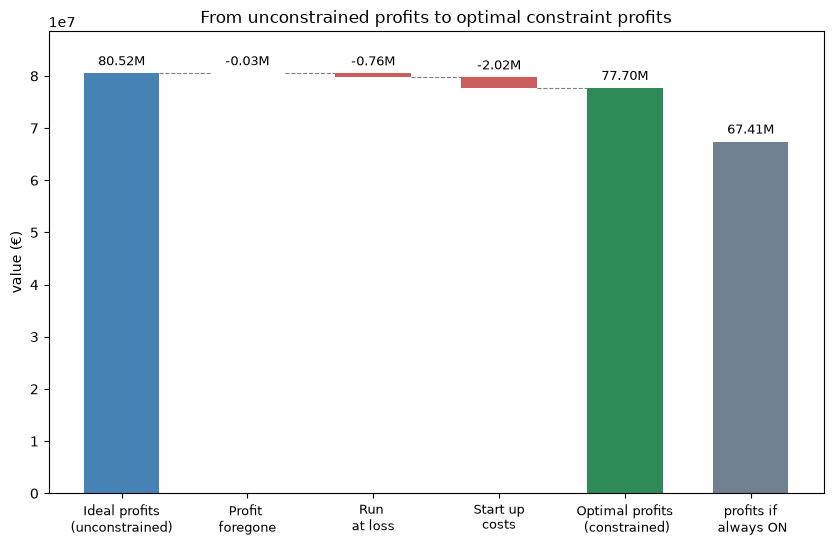

In [9]:
fig, ax = plotting.plot_value_waterfall(
    spark_spread=pun_ttf_prices["spark_spread"],
    is_on=is_on_dispatch,
    capacity=CCGT_POWER,
    n_startups=n_startups,
    switch_on_cost=SWITCH_ON_COST,
    value_optimal_dp=optimal_real_revs,
)
fig.savefig("output/value_waterfall.png", dpi=150, bbox_inches="tight")

# Monte Carlo

diagnostic OK: 8760 hours, 365 days (363 x 24h, one 23h, one 25h), no missing values
diagnostic OK: 8784 hours, 366 days (364 x 24h, one 23h, one 25h), no missing values
diagnostic OK: 8760 hours, 365 days (363 x 24h, one 23h, one 25h), no missing values
Monte Carlo valuation — 1000 scenarios (perfect-foresight upper bound)
  mean:            73 029 505 EUR
  median:          72 786 241 EUR
  std dev:         5 503 588 EUR
  5th–95th pct:    64 331 725 — 82 463 492 EUR
  min / max:       58 411 488 / 89 793 969 EUR
Monte Carlo — number of start-ups per year (1000 scenarios)
  mean:            145.6
  median:          146
  std dev:         19.5
  5th–95th pct:    113 — 176
  min / max:       81 / 196


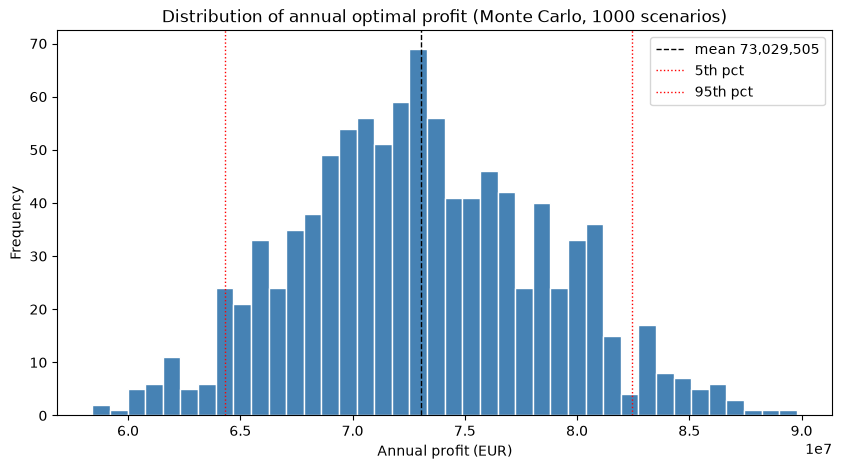

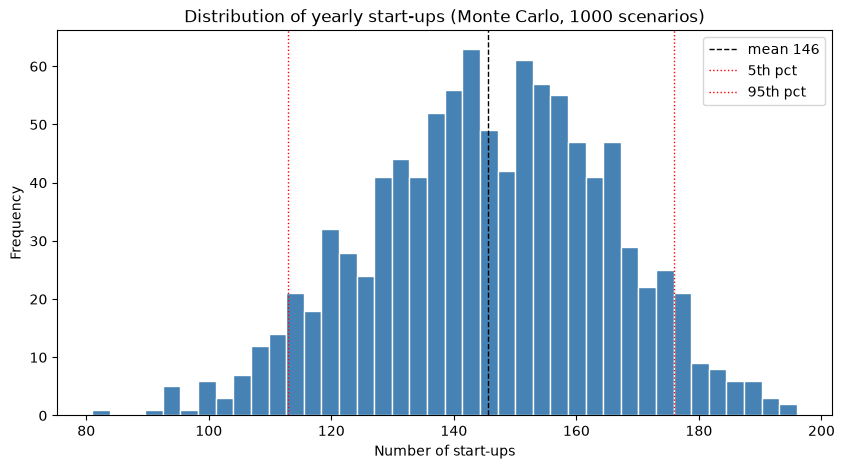

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Distribution of yearly start-ups (Monte Carlo, 1000 scenarios)'}, xlabel='Number of start-ups', ylabel='Frequency'>)

In [13]:
past_years=(2023, 2024, 2025)
df_spark_spread=pd.DataFrame()

for year in past_years:
    df=data_loader.load_pun_ttf_prices(diagnostic=True, year=year)
    df["spark_spread"]=dispatch.compute_spark_spread(
        pun_price=df["pun_price"], 
        ttf_price=df["ttf_price"], 
        heat_rate=HEAT_RATE, 
        emission_factor=EMISSION_FACTOR, 
        co2_price=CO2_PRICE,
    )
    df_spark_spread=pd.concat([df_spark_spread, df], ignore_index=True)

df_spark_spread = df_spark_spread[
    df_spark_spread["time"].dt.date != pd.Timestamp("2024-02-29").date()
]




generate_year=partial(scenarios.generate_year_bootstrap_monthly, df_spark_spread)

profits_montecarlo, n_startups_montecarlo=dispatch.monte_carlo_profits(
    year_generator=generate_year, 
    constraints=constraints, 
    n_scenarios=1000
    )

profits = np.array(profits_montecarlo)
startups=np.array(n_startups_montecarlo)

# --- summary numerico ---
mean = profits.mean()
std = profits.std()
p5, p50, p95 = np.percentile(profits, [5, 50, 95])

def fmt(x):
    return f"{x:,.0f}".replace(",", " ")

print("Monte Carlo valuation — 1000 scenarios (perfect-foresight upper bound)")
print(f"  mean:            {fmt(mean)} EUR")
print(f"  median:          {fmt(p50)} EUR")
print(f"  std dev:         {fmt(std)} EUR")
print(f"  5th–95th pct:    {fmt(p5)} — {fmt(p95)} EUR")
print(f"  min / max:       {fmt(profits.min())} / {fmt(profits.max())} EUR")

def fmt(x):
    return f"{x:,.0f}".replace(",", " ")

print("Monte Carlo — number of start-ups per year (1000 scenarios)")
print(f"  mean:            {startups.mean():.1f}")
print(f"  median:          {np.median(startups):.0f}")
print(f"  std dev:         {startups.std():.1f}")
print(f"  5th–95th pct:    {np.percentile(startups, 5):.0f} — {np.percentile(startups, 95):.0f}")
print(f"  min / max:       {startups.min()} / {startups.max()}")

plotting.plot_distribution(
    profits_montecarlo,
    title="Distribution of annual optimal profit (Monte Carlo, 1000 scenarios)",
    xlabel="Annual profit (EUR)",
)

plotting.plot_distribution(
    n_startups_montecarlo,
    title="Distribution of yearly start-ups (Monte Carlo, 1000 scenarios)",
    xlabel="Number of start-ups",
)